In [14]:
!git clone https://github.com/RohitPoduval1/csci5527-project.git

Cloning into 'csci5527-project'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 57 (delta 20), reused 42 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 1.78 MiB | 8.21 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [2]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 79.5 MB/s eta 0:00:00


# Getting the Data

In [1]:
import kagglehub

fer_path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", fer_path)

Path to dataset files: /Users/chenyixin/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [2]:
import sys

sys.path.append('/content/csci5527-project')

# Import FERDataset and use like a normal Dataset
from fer_dataset import FERDataset

# Dataset

In [3]:
from collections import Counter

import matplotlib.pyplot as plt

## Loading

In [4]:
from fer_dataset import FERDataset
train_dataset = FERDataset(fer_path=fer_path, split='train')
print(f"{len(train_dataset)} training examples")

28709 training examples


In [5]:
test_dataset = FERDataset(fer_path=fer_path, split='test')
print(f"{len(test_dataset)} test examples")

7178 test examples


In [33]:
train_dataset.classes

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [35]:
import matplotlib.pyplot as plt
import numpy as np
arr = test_dataset[0][0].numpy()
arr = arr.squeeze()[0]
plt.imshow(arr, cmap='gray')

AttributeError: 'Image' object has no attribute 'numpy'

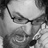

In [6]:
test_dataset[0][0]

## Exploration

In [9]:
readable_training_labels = list(map(lambda i: train_dataset.classes[i], train_dataset.labels))
readable_training_labels = list(map(lambda label: label.title(), readable_training_labels))
readable_training_labels[:5]

['Angry', 'Angry', 'Angry', 'Angry', 'Angry']

In [10]:
training_labels_value_counts = dict(Counter(readable_training_labels))
training_labels_value_counts

{'Angry': 3995,
 'Disgust': 436,
 'Fear': 4097,
 'Happy': 7215,
 'Neutral': 4965,
 'Sad': 4830,
 'Surprise': 3171}

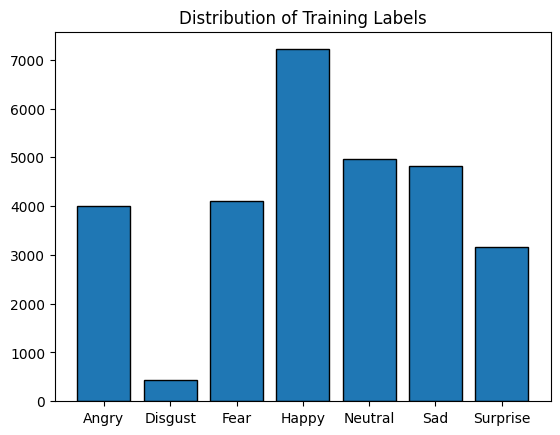

In [11]:
emotions = list(training_labels_value_counts.keys())
counts = list(training_labels_value_counts.values())
plt.bar(emotions, counts, edgecolor='black')
plt.title("Distribution of Training Labels")
plt.show()

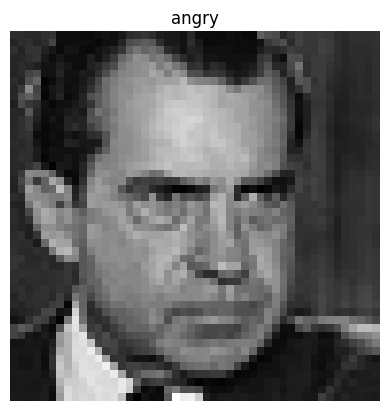

In [12]:
idx = 1
plt.imshow(train_dataset[idx][0], cmap='gray')
plt.title(train_dataset.classes[train_dataset[idx][1]])
plt.axis('off')
plt.show()

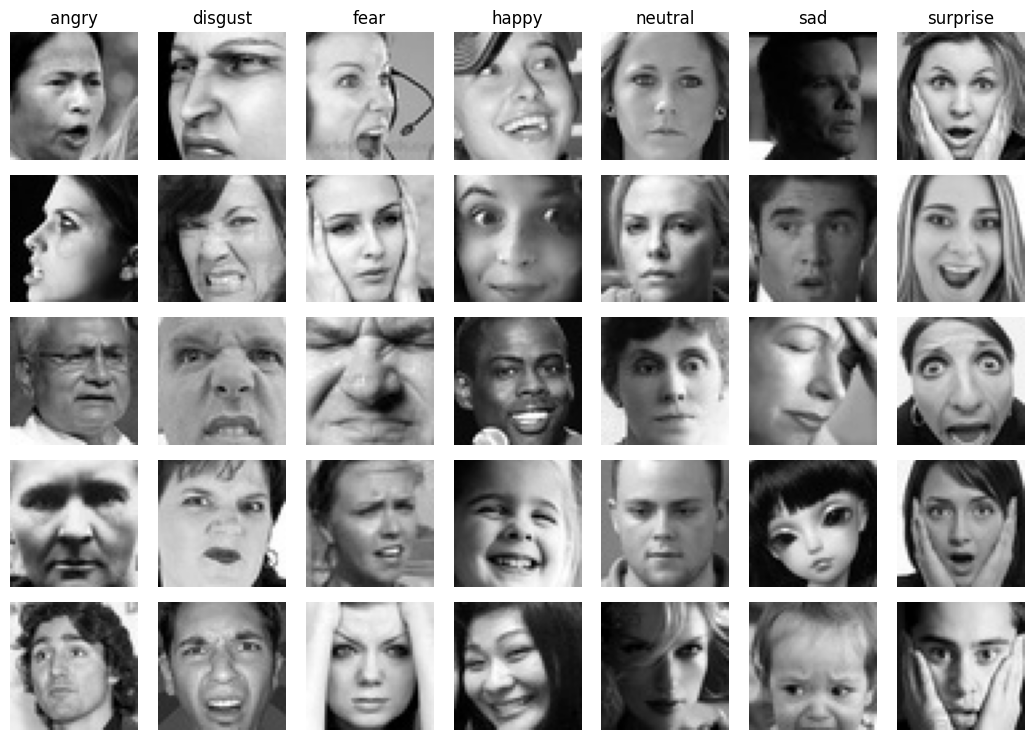

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch

num_images_per_col = 5
classes = train_dataset.classes
num_classes = len(classes)

targets = np.array(train_dataset.labels)

fig, axes = plt.subplots(
  nrows=num_images_per_col,
  ncols=num_classes,
  figsize=(num_classes * 1.5, num_images_per_col * 1.5)
)

# 3. Populate the grid
for class_idx, class_name in enumerate(classes):
  class_indices = np.where(targets == class_idx)[0]

  samples = min(num_images_per_col, len(class_indices))

  # Randomly select indices so we get a variety of faces each time we run it
  selected_indices = np.random.choice(class_indices, samples, replace=False)

  for row_idx in range(num_images_per_col):
    # Select the specific subplot: [row, column]
    ax = axes[row_idx, class_idx]

    if row_idx < samples:
      dataset_idx = selected_indices[row_idx]

      # Fetch image and label from train_dataset
      img, _ = train_dataset[dataset_idx]

      ax.imshow(img, cmap='gray')

      # Only set the title on the very first row to act as column headers
      if row_idx == 0:
        ax.set_title(class_name)

    # Turn off axes for a cleaner look
    ax.axis('off')

plt.tight_layout()
plt.show()

## Transforms

In [14]:
import torchvision.transforms as transforms

In [15]:
transforms = transforms.Compose([
  # Grayscale (1 channel) -> 3 channels
  transforms.Grayscale(num_output_channels=3),

  # 224x224 is standard image size for ImageNet pretrained models
  transforms.Resize((224, 224)),

  transforms.ToTensor(),

  # Normalize using standard ImageNet mean and standard deviation
  transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
  )
])

In [16]:
train_dataset = FERDataset(fer_path=fer_path, split='train', transforms=transforms)
len(train_dataset)

28709

In [17]:
test_dataset = FERDataset(fer_path=fer_path, split='test', transforms=transforms)
len(test_dataset)

7178

# Model & Training

"The researchers **unfroze all layers** in the proposed model and trained the networks for 30 epochs. The results show that using SGD with imbalanced training data and **no frozen layer** gave the best result of all the experiments, with **69.46% test accuracy**, which is M17."

"The researchers used learning rate value of 0.001, 0.9 for momentum on SGD optimizer, and batch size of 32."

In [18]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision

In [19]:
import pytorch_lightning as pl

torch.set_float32_matmul_precision('medium')

## Setup

In [20]:
class VGG16EmotionClassifier(pl.LightningModule):
  def __init__(self):
    super().__init__()
    self.learning_rate = 0.001
    self.momentum = 0.9

    self.model = torchvision.models.vgg16(pretrained=True)
    self.model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.model.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512, 7)
    )

    # Frozen layers have the parameter values preserved
    # Unfreezing a layer simply means the parameters are updatable
    for param in self.model.parameters():
      param.requires_grad = True


  def forward(self, x):
    return self.model(x)


  def training_step(self, batch, batch_idx):
    x, y = batch
    logits = self(x)
    loss = F.cross_entropy(logits, y)

    # Automatically logs the training loss for plotting
    self.log('train_loss', loss)
    return loss


  def validation_step(self, batch, batch_idx):
    x, y = batch
    logits = self(x)
    loss = F.cross_entropy(logits, y)
    preds = torch.argmax(logits, dim=1)
    acc = (preds == y).float().mean()

    # Automatically logs validation metrics
    self.log('val_loss', loss, prog_bar=True)
    self.log('val_acc', acc, prog_bar=True)


  def test_step(self, batch, batch_idx):
    x, y = batch
    logits = self(x)
    loss = F.cross_entropy(logits, y)
    preds = torch.argmax(logits, dim=1)
    acc = (preds == y).float().mean()

    # Log the final test metrics
    self.log('test_loss', loss)
    self.log('test_acc', acc)


  def configure_optimizers(self):
    optimizer = torch.optim.SGD(
      self.parameters(),
      lr=self.learning_rate, momentum=self.momentum
    )
    return optimizer

## DataLoaders

In [21]:
from torch.utils.data import random_split, DataLoader

In [22]:
val_size = len(test_dataset) // 2
test_size = len(test_dataset) - val_size

# Split the Kaggle test set into Validation (10%) and Test (10%)
val_dataset, true_test_dataset = random_split(test_dataset, [val_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=11)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=11)
test_dataloader = DataLoader(true_test_dataset, batch_size=32, shuffle=False, num_workers=11)

## Let's Do It

In [23]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint

In [24]:
# Initialize the Lightning Module
model = VGG16EmotionClassifier()

early_stop_callback = EarlyStopping(
  monitor='val_acc',
  min_delta=0.00,
  patience=10, # Stop if no improvement for 10 epochs
  verbose=True,
  mode='max'
)

checkpoint_callback = ModelCheckpoint(
  dirpath='./', # Save path in your Drive
  filename='vgg16-emotion-{epoch:02d}-{val_acc:.2f}',
  save_top_k=1,
  monitor='val_acc',
  mode='max'
)

trainer = Trainer(
  max_epochs=100,
  min_epochs=30,
  callbacks=[early_stop_callback, checkpoint_callback],
  accelerator='auto',
  devices=1,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 236MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [25]:
# Train the model (Early stopping will use the validation set!)
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ VGG  │ 14.7 M │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 14.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 14.7 M                                                                                               
Total estimated model params size (MB): 58                                                                         
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved. New best score: 0.563
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.025 >= min_delta = 0.0. New best score: 0.588
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.044 >= min_delta = 0.0. New best score: 0.632
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.006 >= min_delta = 0.0. New best score: 0.638
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.016 >= min_delta = 0.0. New best score: 0.654
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.016 >= min_delta = 0.0. New best score: 0.670
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.001 >= min_delta = 0.0. New best score: 0.671
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.009 >= min_delta = 0.0. New best score: 0.680
INFO:pytorch_lightning.callbacks.early_stopp

In [26]:
# Evaluate on the totally unseen test set
# This will automatically load the best weights found during training
trainer.test(model, dataloaders=test_dataloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6762329339981079     │
│         test_loss         │    1.9584494829177856     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.9584494829177856, 'test_acc': 0.6762329339981079}]

In [27]:
import torch

# 1. Mount Drive if not already mounted
# from google.colab import drive
# drive.mount('/content/drive')

# 2. Extract just the raw VGG-16 weights from the Lightning module
# and save them as a standard PyTorch dictionary
torch.save(model.model.state_dict(), "model_early_stop.pth")

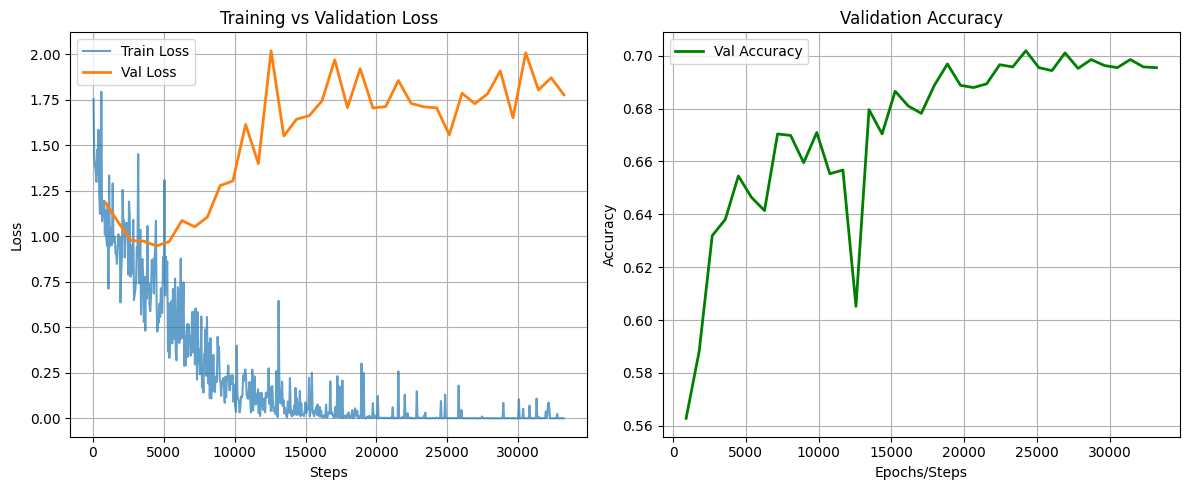

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# 1. Point to your specific log folder
# (Check your file explorer to see if you are on version_0, version_1, etc.)
log_dir = "lightning_logs/version_0"

# 2. Load the TensorBoard event file
event_acc = EventAccumulator(log_dir)
event_acc.Reload()

# Optional: Print out the exact names of the metrics you saved
# print("Available metrics:", event_acc.Tags()['scalars'])

# 3. Extract your specific metrics
train_loss_events = event_acc.Scalars('train_loss')
val_loss_events = event_acc.Scalars('val_loss')
val_acc_events = event_acc.Scalars('val_acc')

# 4. Convert them into clean Pandas DataFrames
df_train_loss = pd.DataFrame([(e.step, e.value) for e in train_loss_events], columns=['step', 'train_loss'])
df_val_loss = pd.DataFrame([(e.step, e.value) for e in val_loss_events], columns=['step', 'val_loss'])
df_val_acc = pd.DataFrame([(e.step, e.value) for e in val_acc_events], columns=['step', 'val_acc'])

# 5. Plot them using Matplotlib!
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(df_train_loss['step'], df_train_loss['train_loss'], label='Train Loss', alpha=0.7)
plt.plot(df_val_loss['step'], df_val_loss['val_loss'], label='Val Loss', linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(df_val_acc['step'], df_val_acc['val_acc'], label='Val Accuracy', color='green', linewidth=2)
plt.title('Validation Accuracy')
plt.xlabel('Epochs/Steps')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()